In [ ]:
NIFTY50_5year_data_filepath = '/content/drive/MyDrive/SEMESTER 4/INT 256/Project/Data/5yearsNIFTY50.csv'
NIFTY50_1year_data_filepath = '/content/drive/MyDrive/SEMESTER 4/INT 256/Project/Data/1yearNIFTY50.csv'

In [ ]:
#All imports required
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.layers as layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
# -----------------------------
# Parameters
# -----------------------------
window_size_1 = 10   # Better context for time series
window_size_2 = 6
window_size_3 = 3
forecast_horizon = 1  # Number of future days you want to predict

In [ ]:


five_years_df = pd.read_csv(NIFTY50_5year_data_filepath)
one_year_df = pd.read_csv(NIFTY50_1year_data_filepath)

# Ensure the date columns are in datetime format
five_years_df['Date'] = pd.to_datetime(five_years_df['Date'])
one_year_df['Date'] = pd.to_datetime(one_year_df['Date'])

# Remove rows in the 5-year dataset that exist in the 1-year dataset
df = five_years_df[~five_years_df['Date'].isin(one_year_df['Date'])]



In [ ]:
# -----------------------------
# Data Loading and Preprocessing
# -----------------------------
# df = pd.read_csv(NIFTY50_1year_data_filepath)

# Convert date and set index
df['Date'] = pd.to_datetime(df['Date']).dt.date
df.set_index('Date', inplace=True)

# Select Close column and clean commas (if any)
df = df['Close'].apply(lambda x: str(x).replace(',', '')).astype(float)

# Convert prices to numpy array
prices = df.to_numpy()
timesteps = df.index.to_numpy()


<ipython-input-199-29d62a653c91>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date']).dt.date


In [ ]:
# -----------------------------
# Splitting the Data (Time Series Split) for window size 10
# -----------------------------
total_length = prices.shape[0]
# train_size = int(0.8 * total_length)

train_prices_raw_10 = prices.reshape(-1, 1)
#test_prices_raw_10 = prices[train_size - window_size_1:].reshape(-1, 1)  # Include overlap for windowing
# -----------------------------
# Splitting the Data (Time Series Split) for window size 10
# -----------------------------

train_prices_raw_6 = prices.reshape(-1, 1)
#test_prices_raw_6 = prices[train_size - window_size_2:].reshape(-1, 1)  # Include overlap for windowing
# -----------------------------
# Splitting the Data (Time Series Split) for window size 10
# -----------------------------

train_prices_raw_3 = prices.reshape(-1, 1)
#test_prices_raw_3 = prices[train_size - window_size_3:].reshape(-1, 1)  # Include overlap for windowing

In [ ]:
# -----------------------------
# Normalize with MinMaxScaler (Fit on training only!)
# -----------------------------
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

train_prices_scaled_10 = scaler.fit_transform(train_prices_raw_10).flatten()
# test_prices_scaled_10 = scaler.transform(test_prices_raw_10).flatten()

train_prices_scaled_6 = scaler.transform(train_prices_raw_6).flatten()
#test_prices_scaled_6 = scaler.transform(test_prices_raw_6).flatten()

train_prices_scaled_3 = scaler.transform(train_prices_raw_3).flatten()
#test_prices_scaled_3 = scaler.transform(test_prices_raw_3).flatten()


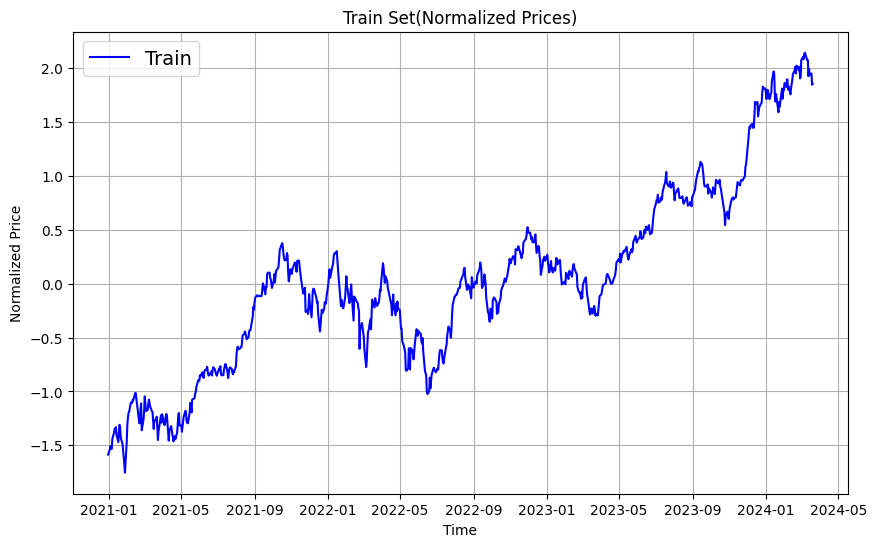

In [ ]:
# -----------------------------
# Plot the scaled train and test splits
# -----------------------------
def plot_time_series(timesteps, values, fmt=".", start=0, end=None, label=None, color="b"):
    plt.plot(timesteps[start:end], values[start:end], fmt, label=label, color=color)
    plt.xlabel("Time")
    plt.ylabel("Normalized Price")
    if label:
        plt.legend(fontsize=14)
    plt.grid(True)

plt.figure(figsize=(10, 6))
plot_time_series(timesteps, train_prices_scaled_10, fmt='-', color='blue', label='Train')
# plot_time_series(timesteps, test_prices_scaled_10[window_size_1:], fmt='-', color='red', label='Test')
plt.title("Train Set(Normalized Prices)")
plt.show()

In [ ]:
# -----------------------------
# Creating the Windowed Dataset Function
# -----------------------------
def windowed_dataset(data, window_size):
    windows = []
    labels = []
    for i in range(len(data) - window_size):
        window_data = data[i: i + window_size]
        label = data[i + window_size]
        windows.append(window_data)
        labels.append(label)
    return np.array(windows), np.array(labels)

# -----------------------------
# Create train, validation, and test datasets
# -----------------------------
# Train Windowed Dataset
X_train_full_10, y_train_full_10 = windowed_dataset(train_prices_scaled_10, window_size_1)
X_train_full_6 ,y_train_full_6 = windowed_dataset(train_prices_scaled_6, window_size_2)
X_train_full_3, y_train_full_3 = windowed_dataset(train_prices_scaled_3, window_size_3)

# Split training into train and validation
X_train_10, X_val_10, y_train_10, y_val_10 = train_test_split(X_train_full_10, y_train_full_10, test_size=0.1, shuffle=False)
X_train_6, X_val_6, y_train_6, y_val_6 = train_test_split(X_train_full_6, y_train_full_6, test_size=0.2, shuffle=False)
X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(X_train_full_3, y_train_full_3, test_size=0.2, shuffle=False)

# Test Windowed Dataset (using overlapped test set)
# X_test_10, y_test_10 = windowed_dataset(test_prices_scaled_10, window_size_1)
# X_test_6, y_test_6 = windowed_dataset(test_prices_scaled_6, window_size_2)
# X_test_3, y_test_3 = windowed_dataset(test_prices_scaled_3, window_size_3)


In [ ]:
df1 = pd.read_csv(NIFTY50_1year_data_filepath)
# Convert date and set index
df1['Date'] = pd.to_datetime(df1['Date']).dt.date
df1.set_index('Date', inplace=True)

# Select Close column and clean commas (if any)
df1 = df1['Close'].apply(lambda x: str(x).replace(',', '')).astype(float)

# Convert prices to numpy array
prices1 = df1.to_numpy()
timesteps1 = df1.index.to_numpy()

test_prices = prices1.reshape(-1, 1)

test_prices_scaled = scaler.transform(test_prices).flatten()

X_test_10, y_test_10 = windowed_dataset(test_prices_scaled, window_size_1)
X_test_6, y_test_6 = windowed_dataset(test_prices_scaled, window_size_2)
X_test_3, y_test_3 = windowed_dataset(test_prices_scaled, window_size_3)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class ExpandDims(Layer):
    def __init__(self, axis=-1, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.expand_dims(inputs, axis=self.axis)

    def compute_output_shape(self, input_shape):
        return input_shape + (1,)

In [ ]:
from tensorflow.keras import layers, Model

# -----------------------------
# Build the Models with ExpandDims
# -----------------------------

## model_10
inputs_10 = layers.Input(shape=(window_size_1,), name="input_window_10")

x_10 = ExpandDims(axis=-1, name="expand_dims_10")(inputs_10)

x_10 = layers.LSTM(128, return_sequences=False, name="lstm_10_sequence_true",)(x_10)

outputs_10 = layers.Dense(1, name="dense_10")(x_10)

model_10 = Model(inputs=inputs_10, outputs=outputs_10, name="LSTM-Forecasting-model-with-window-size-10")
model_10.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(0.01), metrics=['mae'])
model_10.summary()

# -----------------------------

## model_6
inputs_6 = layers.Input(shape=(window_size_2,), name="input_window_6")
x_6 = ExpandDims(axis=-1, name="expand_dims_6")(inputs_6)


x_6 = layers.LSTM(192, return_sequences=False, name="lstm_6_sequence_false")(x_6)

outputs_6 = layers.Dense(1, name="dense_6")(x_6)

model_6 = Model(inputs=inputs_6, outputs=outputs_6, name="LSTM-Forecasting-model-with-window-size-6")
model_6.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(0.01), metrics=['mae'])
model_6.summary()

# -----------------------------

## model_3
inputs_3 = layers.Input(shape=(window_size_3,), name="input_window_3")
x_3 = ExpandDims(axis=-1, name="expand_dims_3")(inputs_3)


x_3 = layers.LSTM(192, return_sequences=False, name="lstm_3_sequence_false")(x_3)

outputs_3 = layers.Dense(1, name="dense_3")(x_3)

model_3 = Model(inputs=inputs_3, outputs=outputs_3, name="LSTM-Forecasting-model-with-window-size-3")
model_3.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(0.01), metrics=['mae'])
model_3.summary()



Model: "LSTM-Forecasting-model-with-window-size-10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_window_10 (InputLayer)         │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ expand_dims_10 (ExpandDims)          │ (None, 10, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_10_sequence_true (LSTM)         │ (None, 128)                 │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 66,689 (260.50 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "LSTM-Forecasting-model-with-window-size-3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_window_3 (InputLayer)          │ (None, 3)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ expand_dims_3 (ExpandDims)           │ (None, 3, 1)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3_sequence_false (LSTM)         │ (None, 192)                 │         148,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             193 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 149,185 (582.75 KB)

 Trainable params: 149,185 (582.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# -----------------------------
# Train the Model
# -----------------------------

In [ ]:

history_10 = model_10.fit(
    X_train_10, y_train_10,
    epochs=50,
    validation_data=(X_val_10, y_val_10),
    batch_size=32
)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0627 - mae: 0.1671 - val_loss: 0.0573 - val_mae: 0.2272
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0087 - mae: 0.0715 - val_loss: 0.0368 - val_mae: 0.1793
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0087 - mae: 0.0723 - val_loss: 0.0082 - val_mae: 0.0706
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0078 - mae: 0.0691 - val_loss: 0.0068 - val_mae: 0.0624
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0063 - mae: 0.0612 - val_loss: 0.0178 - val_mae: 0.1126
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0080 - mae: 0.0685 - val_loss: 0.0119 - val_mae: 0.0914
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0064 - mae: 0.0613 - val_loss: 0.0131 - val_mae: 0.0973
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0062 - mae: 0.0610 - val_loss: 0.0230 - val_mae: 0.1378
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.005

KeyboardInterrupt: 

In [ ]:
history_6 = model_6.fit(
    X_train_6, y_train_6,
    epochs=50,
    validation_data=(X_val_6, y_val_6),
    batch_size=32
)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.1052 - mae: 0.2145 - val_loss: 0.0167 - val_mae: 0.0978
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0119 - mae: 0.0837 - val_loss: 0.0153 - val_mae: 0.1034
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0118 - mae: 0.0864 - val_loss: 0.1047 - val_mae: 0.2448
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0096 - mae: 0.0772 - val_loss: 0.1721 - val_mae: 0.3306
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0088 - mae: 0.0730 - val_loss: 0.0496 - val_mae: 0.2016
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0089 - mae: 0.0739 - val_loss: 0.0069 - val_mae: 0.0678
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0076 - mae: 0.0674 - val_loss: 0.0050 - val_mae: 0.0546
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0064 - mae: 0.0633 - val_loss: 0.0052 - val_mae: 0.0562
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.005

In [ ]:
history_3 = model_3.fit(
    X_train_3, y_train_3,
    epochs=50,
    validation_data=(X_val_3, y_val_3),
    batch_size=32
)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0913 - mae: 0.2161 - val_loss: 0.0226 - val_mae: 0.1307
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0116 - mae: 0.0845 - val_loss: 0.0203 - val_mae: 0.1116
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0091 - mae: 0.0738 - val_loss: 0.0197 - val_mae: 0.1091
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0086 - mae: 0.0713 - val_loss: 0.0442 - val_mae: 0.1658
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0090 - mae: 0.0752 - val_loss: 0.0287 - val_mae: 0.1434
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0088 - mae: 0.0707 - val_loss: 0.0118 - val_mae: 0.0911
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0081 - mae: 0.0698 - val_loss: 0.0146 - val_mae: 0.1008
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0070 - mae: 0.0645 - val_loss: 0.0045 - val_mae: 0.0508
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.006

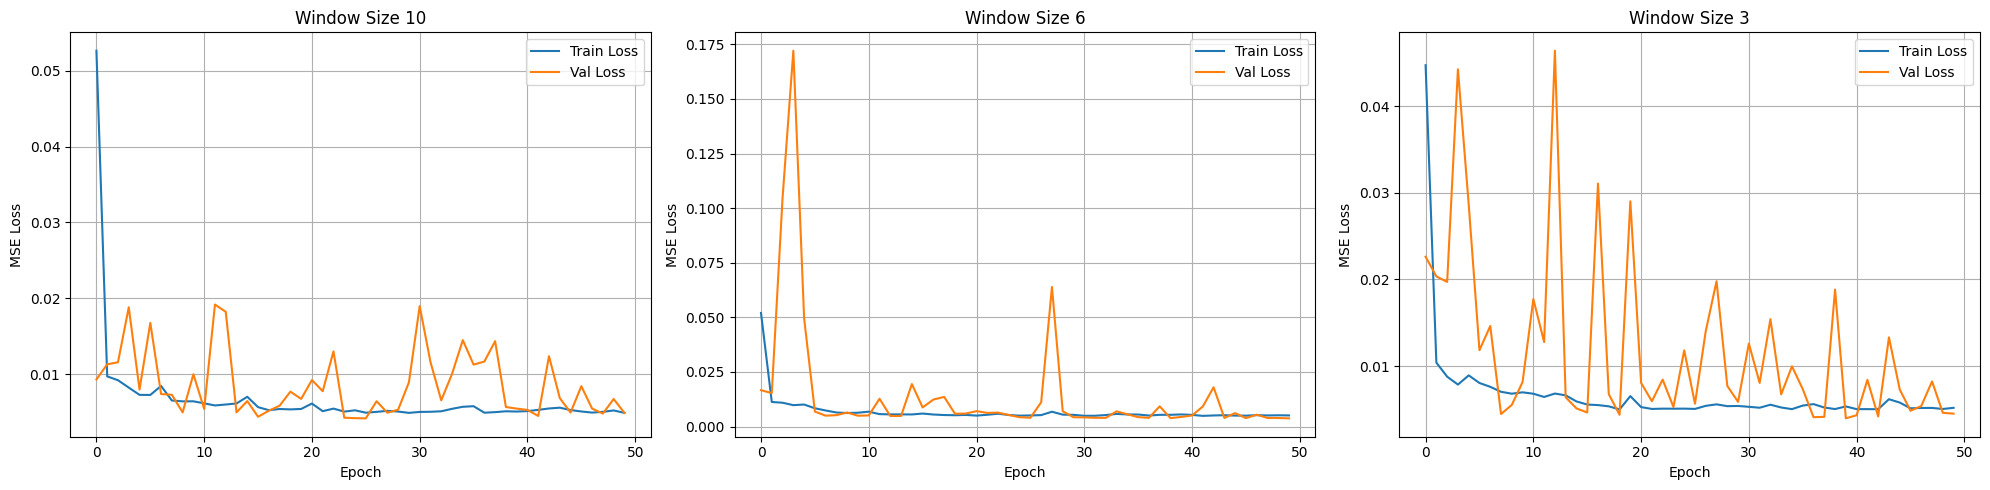

In [ ]:
# -----------------------------
# Plot Training & Validation Loss for all three models
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # Adjusted figsize for better visibility

# Model with window size 10
axes[0].plot(history_10.history['loss'], label='Train Loss')
axes[0].plot(history_10.history['val_loss'], label='Val Loss')
axes[0].set_title("Window Size 10")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# Model with window size 6
axes[1].plot(history_6.history['loss'], label='Train Loss')
axes[1].plot(history_6.history['val_loss'], label='Val Loss')
axes[1].set_title("Window Size 6")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True)

# Model with window size 3
axes[2].plot(history_3.history['loss'], label='Train Loss')
axes[2].plot(history_3.history['val_loss'], label='Val Loss')
axes[2].set_title("Window Size 3")
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()  # Adjust subplot parameters for a tight layout
plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


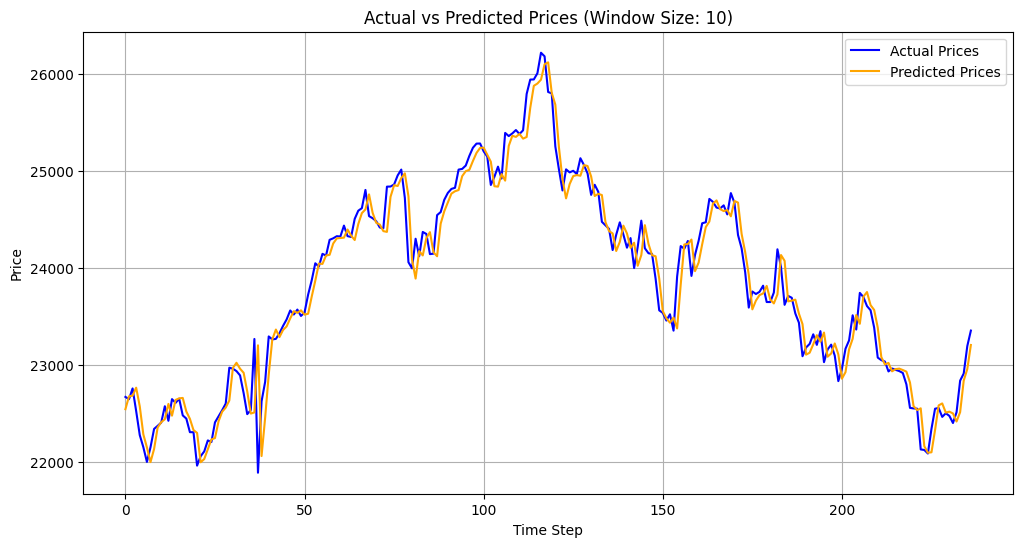

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


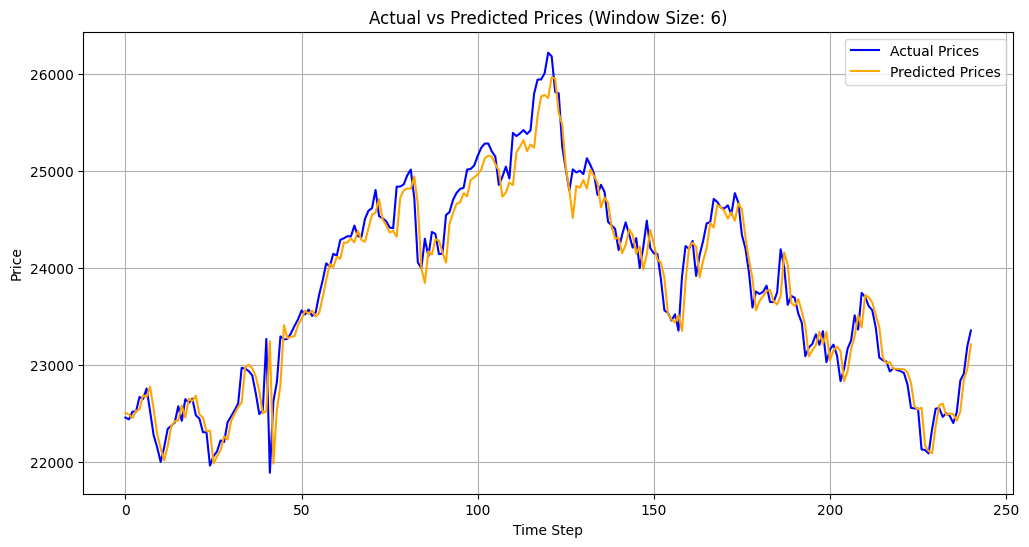

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


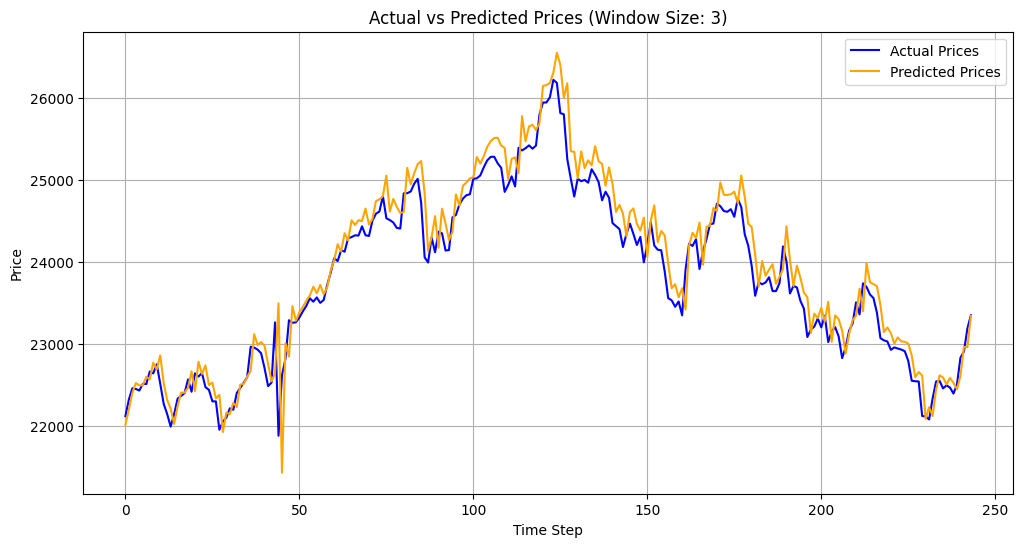

In [ ]:
# -----------------------------
# Predict and Compare on Test Set (for each model)
# -----------------------------
def plot_predictions(model, X_test, y_test, window_size, scaler):
    """Plots predictions against actual values."""
    predictions_scaled = model.predict(X_test)
    predictions_unscaled = scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
    y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    plt.figure(figsize = (12, 6))
    plt.plot(y_test_unscaled, label="Actual Prices", color='blue')
    plt.plot(predictions_unscaled, label="Predicted Prices", color='orange')
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.title(f"Actual vs Predicted Prices (Window Size: {window_size})")
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot predictions for each model
plot_predictions(model_10, X_test_10, y_test_10, window_size_1, scaler)
plot_predictions(model_6, X_test_6, y_test_6, window_size_2, scaler)
plot_predictions(model_3, X_test_3, y_test_3, window_size_3, scaler)

In [ ]:
import joblib
import tensorflow as tf
joblib.dump(scaler, '/content/drive/MyDrive/SEMESTER 4/INT 256/Project/RobustScaler[5].save')
model_10.save('/content/drive/MyDrive/SEMESTER 4/INT 256/Project/model[10,RS,5].keras')
model_6.save('/content/drive/MyDrive/SEMESTER 4/INT 256/Project/model[6,RS,5].keras')
model_3.save('/content/drive/MyDrive/SEMESTER 4/INT 256/Project/model[3,RS,5].keras')